# **What is a neural Network?**

A neural network in machine learning is a type of artificial intelligence algorithm modeled after the structure and function of the human brain. It consists of interconnected nodes, called artificial neurons, that are organized in layers and connected with weighted connections. The neurons in the input layer receive input data, which is processed and transformed as it passes through the hidden layers, until the final output is produced by the output layer. Neural networks are capable of learning patterns in data, and can be used for a wide range of tasks, such as image recognition, natural language processing, and prediction. They are trained using a labeled dataset and an optimization algorithm, such as gradient descent, to minimize the prediction error.  
For our scenario, we'll use it on the housing dataset with a labeled dataset.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import keras
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


# Exploring our Data

In [2]:
df=pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
df_test=pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')
df_train=pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')

We have plenty of features to look at and engineer to get an accurate output for our tree based models. We first begin with feature engineering and then we can move onto the various different models, and then choosing our ideal model and submitting the output

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


As you can see, we have a lot of columns with null values. Why is that? this is because certain columns are based on features dependent on there presence in the house.  
For example, PoolQC which stands for the pool quality would obviously be empty for a house with no pool. Similairly, there are many such columns for which we can engineer and clean our data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

We do have a number of strong features which provide a high enough signal to even independently give an accurate output on its own. Some examples include the overall quality of the house which is extremely highly correlated. Fascinating!

In [5]:
df.corr()['SalePrice'].sort_values()

KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
LowQualFinSF    -0.025606
Id              -0.021917
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
3SsnPorch        0.044584
MoSold           0.046432
PoolArea         0.092404
ScreenPorch      0.111447
BedroomAbvGr     0.168213
BsmtUnfSF        0.214479
BsmtFullBath     0.227122
LotArea          0.263843
HalfBath         0.284108
OpenPorchSF      0.315856
2ndFlrSF         0.319334
WoodDeckSF       0.324413
LotFrontage      0.351799
BsmtFinSF1       0.386420
Fireplaces       0.466929
MasVnrArea       0.477493
GarageYrBlt      0.486362
YearRemodAdd     0.507101
YearBuilt        0.522897
TotRmsAbvGrd     0.533723
FullBath         0.560664
1stFlrSF         0.605852
TotalBsmtSF      0.613581
GarageArea       0.623431
GarageCars       0.640409
GrLivArea        0.708624
OverallQual      0.790982
SalePrice        1.000000
Name: SalePr

<AxesSubplot:>

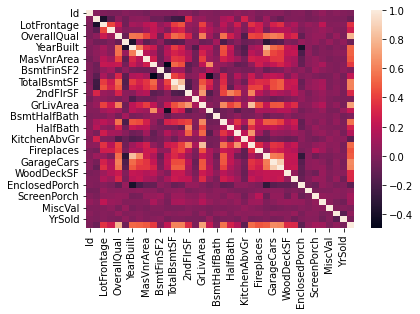

In [6]:
cor=df.corr()
sns.heatmap(cor)

Now that we've glanced through our data, lets begin cleaning it and making it ready for our model!

# Dealing with Outliers

We can see that there are 2 particular houses in the training set that are really large and have a very low price. This is harmful data as it confuses our model, and also because by intuition, we know a larger house should have a higher price. Since there are ony 2 of these, lets go ahead and remove them now.

<AxesSubplot:xlabel='GrLivArea', ylabel='SalePrice'>

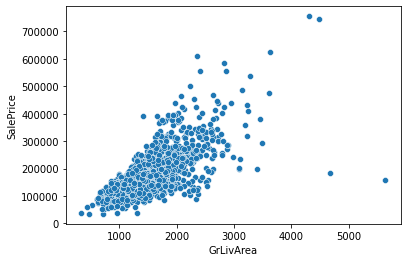

In [7]:
sns.scatterplot(data=df,x='GrLivArea',y='SalePrice')

<AxesSubplot:xlabel='GrLivArea', ylabel='SalePrice'>

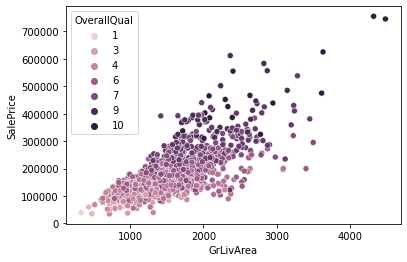

In [8]:
df=df.drop(df[(df['GrLivArea']>4000) & (df['SalePrice']<300000)].index)
sns.scatterplot(data=df,x='GrLivArea',y='SalePrice',hue='OverallQual')

# Dealing with Missing Data  
In order to save us time, I'll proceed to merge both the training and test set so that we can simultaneously perform operations on them, we will later however seperate them during submission and training them.

In [9]:
ntrain = df_train.shape[0]
ntest = df_test.shape[0]
y_train = df_train.SalePrice.values
df = pd.concat((df_train, df_test)).reset_index(drop=True)

In [10]:
def percent_missing(df):
    percent_nan = 100* df.isnull().sum() / len(df)
    percent_nan = percent_nan[percent_nan>0].sort_values()
    return percent_nan

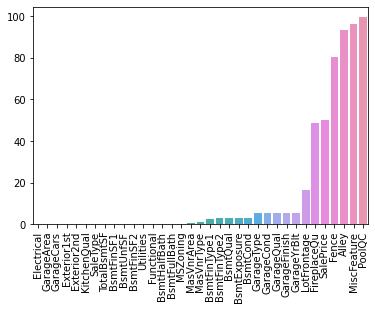

In [11]:
percent_nan = percent_missing(df)
sns.barplot(x=percent_nan.index,y=percent_nan)
plt.xticks(rotation=90);

Woah! there are some columns which have almost all there rows missing values. These columns are some such as PoolQC, Alley, Fence, etc. From reading the data documentation, the null values mean that these features are not present and have been given a null value. We'll go ahead and replace them with the word 'None'.

In [12]:
df["PoolQC"] = df["PoolQC"].fillna("None")

In [13]:
df["MiscFeature"] = df["MiscFeature"].fillna("None")

In [14]:
df["Alley"] = df["Alley"].fillna("None")

In [15]:
df["Fence"] = df["Fence"].fillna("None")

In [16]:
df["FireplaceQu"] = df["FireplaceQu"].fillna("None")

For the LotFrontage, we will assume that the houses have the same frontage as that of its similair types. We will perform a groupby operation and fill it with the mean value of that neighborhoods lot frontage.

In [17]:
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.mean()))

In [18]:
for column in ('GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'):
    df[column] = df[column].fillna('None')

In [19]:
for column in ('GarageYrBlt', 'GarageArea', 'GarageCars'):
    df[column] = df[column].fillna(0)


In [20]:
for column in ('BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath'):
    df[column] = df[column].fillna(0)

In [21]:
for column in ('BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'):
    df[column] = df[column].fillna('None')

In [22]:
df["MasVnrType"] = df["MasVnrType"].fillna("None")
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

In [23]:
df['MSZoning'] = df['MSZoning'].fillna(df['MSZoning'].mode()[0])

In [24]:
df = df.drop(['Utilities'], axis=1)

In [25]:
df["Functional"] = df["Functional"].fillna("Typ")

In [26]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])


In [27]:
df['KitchenQual'] = df['KitchenQual'].fillna(df['KitchenQual'].mode()[0])


In [28]:
df['Exterior1st'] = df['Exterior1st'].fillna(df['Exterior1st'].mode()[0])
df['Exterior2nd'] = df['Exterior2nd'].fillna(df['Exterior2nd'].mode()[0])


In [29]:
df['SaleType'] = df['SaleType'].fillna(df['SaleType'].mode()[0])


In [30]:
df['MSSubClass'] = df['MSSubClass'].fillna("None")


Lets go! We've successfully cleaned our data. The only column left with null values are those from the saleprice of the test set. Dont worry, we'll make sure to seperate them later on for our model and submission!

In [31]:
df.isnull()['SalePrice']

0       False
1       False
2       False
3       False
4       False
        ...  
2914     True
2915     True
2916     True
2917     True
2918     True
Name: SalePrice, Length: 2919, dtype: bool

# Dealing with Categorical Data  
We can now move onto the categorical data. Some of the columns have numbers in them but represent a category and not a numerical entity. Lets go ahead and replace them into string types.

In [32]:
df['MSSubClass'] = df['MSSubClass'].apply(str)
df['OverallCond'] = df['OverallCond'].apply(str)
df['YrSold'] = df['YrSold'].astype(str)
df['MoSold'] = df['MoSold'].astype(str)

For the rest of the columns, they have some sort of order to them and require label encoding them. Lets go ahead and do that with the label encoder.

In [33]:
cols = ['FireplaceQu', 'BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond', 
        'ExterQual', 'ExterCond','HeatingQC', 'PoolQC', 'KitchenQual', 'BsmtFinType1', 
        'BsmtFinType2', 'Functional', 'Fence', 'BsmtExposure', 'GarageFinish', 'LandSlope',
        'LotShape', 'PavedDrive', 'Street', 'Alley', 'CentralAir', 'MSSubClass', 'OverallCond', 
        'YrSold', 'MoSold']

for c in cols:
    lbl = LabelEncoder() 
    lbl.fit(list(df[c].values)) 
    df[c] = lbl.transform(list(df[c].values))

Now all we have left are the categorical data which require one hot encoding. Lets use the get_dummies function for getting all the encodings. We'll do this for all the columns, since there isn't much disadvantages to this anyways...

In [34]:
df = pd.get_dummies(df)
print(df.shape)

df_test = pd.get_dummies(df_test)

(2919, 222)


# Creating our Model using Keras and TF  
Keras is an open-source software library that provides a Python interface for ANNs (Artificial Neural Networks). It is capable of running on top of TensorFlow, CNTK, or Theano. Keras was developed to make it easier to experiment with different ANN architectures. It has a user-friendly API and is written in Python, which makes it easy for developers to get started with deep learning.Keras runs on top of TensorFlow, making it easier to use TensorFlow functionality in a more user-friendly and higher-level way.  


Lets seperate and create our test and train splits before we move onto our ANN model.

In [35]:
X=df.drop('SalePrice',axis=1)[:ntrain]
y=df['SalePrice'][:ntrain]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=101)
X_train.shape

(1168, 221)

We'll also do all the neccessary imports from tensorflow such as BatchNormalization, Dropout, the main regressor model, etc. We'll set a seed for reproducable outcomes too!

In [37]:
from tensorflow.keras.layers import BatchNormalization
from keras.models import Sequential
from keras.layers import Dense
from keras.wrappers.scikit_learn import KerasRegressor
import tensorflow as tf
seed = 7
np.random.seed(seed)

*Keras provides the sequential API for us to create simple and easy to use neural networks.*

What is BatchNormalization and Dropout?  

Batch normalization and dropout are two techniques used to improve the performance of deep learning models.

Batch normalization: This is a method to normalize the inputs to a layer in a neural network, in order to stabilize the training process and prevent overfitting. It involves normalizing the inputs to have a mean of zero and a standard deviation of one, so that the inputs are always roughly the same scale.

Dropout: This is a technique used to prevent overfitting, where some of the neurons in a layer are randomly dropped out (ignored) during each training step. This helps to reduce the dependence of the model on any one neuron, and also provides a kind of regularization, where the model is forced to find a solution that works well even with some neurons ignored.


In [38]:

model = Sequential()
BatchNormalization()
model.add(Dense(1028,input_dim=221,activation='relu'))
BatchNormalization()
model.add(Dense(1028,input_dim=221,activation='relu'))
BatchNormalization()
#Dropout(0.2)
model.add(Dense(100,input_dim=221,activation='relu'))
BatchNormalization()
#Dropout(0.2)
model.add(Dense(50))
BatchNormalization()
model.add(Dense(1))


model.compile(optimizer='adam',loss='mse',metrics=['accuracy'])


2023-02-08 07:03:37.920400: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


**How does our Neural Network learn?**  
Neural network learns by adjusting its weights and biases through the process of training, using a labeled dataset and an optimization algorithm such as gradient descent. During the training process, the network makes predictions on the input data and compares its output to the true labels. Based on the difference between the predicted and true labels, the network adjusts its weights and biases to reduce the error and improve its accuracy. This process is repeated multiple times until the error is minimized, and the network can make accurate predictions on new data.

In [39]:
from tensorflow.keras import layers, callbacks
history=model.fit(X_train, y_train,validation_data=(X_test, y_test),batch_size=512,epochs=50,verbose=0) # suppress output since we'll plot the curves)


2023-02-08 07:03:38.235973: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Minimum Validation Loss: 3156775424.0000


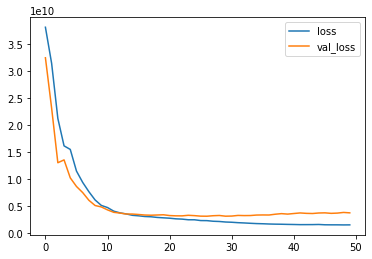

In [40]:
history_df = pd.DataFrame(history.history)
history_df.loc[0:, ['loss', 'val_loss']].plot()
print("Minimum Validation Loss: {:0.4f}".format(history_df['val_loss'].min()));

In [41]:
test_preds = model.predict(X_test)
np.sqrt(mean_squared_error(y_test,test_preds))

61479.49889309127

# Submission  
We'll go back to our concatenated dataframe and seperate the test data out so that we can create our submission.

In [42]:
df[ntest+1:]['SalePrice']

1460   NaN
1461   NaN
1462   NaN
1463   NaN
1464   NaN
        ..
2914   NaN
2915   NaN
2916   NaN
2917   NaN
2918   NaN
Name: SalePrice, Length: 1459, dtype: float64

In [43]:
y_submission = model.predict(df[ntest+1:].drop('SalePrice',axis=1))
list=[]
for i in range(1459):
    list.append(y_submission[i][0])


In [44]:

df_pred = pd.DataFrame({'Id': df_test['Id'], 'SalePrice': list})
df_pred.to_csv('submission.csv', index = False)

This model yielded a pretty meh score! Why is that? this is because neural networks tend to perform best when the number of samples provided to it are extremely large, such as in the range of 10,000+. Since we do not have this type of dataset, the model seemed to perform very poorly. 
Anyways, thats all for today, cheers!